In [1]:
import config 
import numpy as np 
from utils.optuna import load_optuna_best_results
from utils.dataset import load_dataset 
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os 

/home/coder/masters_thesis/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
CURRENT_DATASET = config.BREASTMNIST


In [3]:
_, _, _, _, _, Y_test = load_dataset(config)
Y_test  = Y_test.reshape(Y_test.shape[0])

In [4]:
def load_scores(results_dir, dataset_name, specialist_name, n_epochs, num_clauses, T_best, s_best, patch_best, maxlit_best, weighted_best):
    file_path = (
        f"{results_dir}/"
        f"{specialist_name}_{n_epochs}_"
        f"{num_clauses}_"
        f"{T_best}_"
        f"{s_best:.1f}_"
        f"{patch_best}_"
        f"{maxlit_best}_"
        f"{weighted_best}.txt"
    )
    return np.loadtxt(file_path, delimiter=",")

In [5]:
best_value, best_params = load_optuna_best_results("hyperparameters/canny_edge.json")
s_best_canny = best_params["s"]
T_best_canny = best_params["T"]
patch_best_canny = best_params["patch_size"]
weighted_best = 1
maxlit_best_canny = best_params["max_included_literals"]

In [6]:
best_value, best_params = load_optuna_best_results("hyperparameters/adaptive_gaussian.json")
s_best_adaptive_gaussian = best_params["s"]
T_best_adaptive_gaussian = best_params["T"]
patch_best_adaptive_gaussian = best_params["patch_size"]
weighted_best = 1
maxlit_best_adaptive_gaussian = best_params["max_included_literals"]

In [7]:
best_value, best_params = load_optuna_best_results("hyperparameters/adaptive_mean.json")
s_best_adaptive_mean = best_params["s"]
T_best_adaptive_mean = best_params["T"]
patch_best_adaptive_mean = best_params["patch_size"]
weighted_best = 1
maxlit_best_adaptive_mean = best_params["max_included_literals"]

In [8]:
best_value, best_params = load_optuna_best_results("hyperparameters/otsu.json")
s_best_otsu = best_params["s"]
T_best_otsu = best_params["T"]
patch_best_otsu = best_params["patch_size"]
weighted_best = 1
maxlit_best_otsu = best_params["max_included_literals"]

In [9]:
best_value, best_params = load_optuna_best_results("hyperparameters/color_thermometers.json")
s_best_thermometer = best_params["s"]
T_best_thermometer = best_params["T"]
patch_best_thermometer = best_params["patch_size"]
weighted_best = 1
maxlit_best_thermometer = best_params["max_included_literals"]

The number of classes is: 2

=== Epoch 1 ===
Accuracy: 71.15%

=== Epoch 2 ===
Accuracy: 83.33%

=== Epoch 3 ===
Accuracy: 81.41%

=== Epoch 4 ===
Accuracy: 80.13%

=== Epoch 5 ===
Accuracy: 81.41%

=== Epoch 6 ===
Accuracy: 82.69%

=== Epoch 7 ===
Accuracy: 84.62%

=== Epoch 8 ===
Accuracy: 82.69%

=== Epoch 9 ===
Accuracy: 85.26%

=== Epoch 10 ===
Accuracy: 84.62%

=== Epoch 11 ===
Accuracy: 85.26%

=== Epoch 12 ===
Accuracy: 85.26%

=== Epoch 13 ===
Accuracy: 85.90%

=== Epoch 14 ===
Accuracy: 84.62%

=== Epoch 15 ===
Accuracy: 85.90%

=== Epoch 16 ===
Accuracy: 85.26%

=== Epoch 17 ===
Accuracy: 85.26%

=== Epoch 18 ===
Accuracy: 85.90%

=== Epoch 19 ===
Accuracy: 85.90%

=== Epoch 20 ===
Accuracy: 86.54%

=== Epoch 21 ===
Accuracy: 86.54%

=== Epoch 22 ===
Accuracy: 85.26%

=== Epoch 23 ===
Accuracy: 86.54%

=== Epoch 24 ===
Accuracy: 86.54%

=== Epoch 25 ===
Accuracy: 85.90%

=== Epoch 26 ===
Accuracy: 87.18%

=== Epoch 27 ===
Accuracy: 87.18%

=== Epoch 28 ===
Accuracy: 86.54%



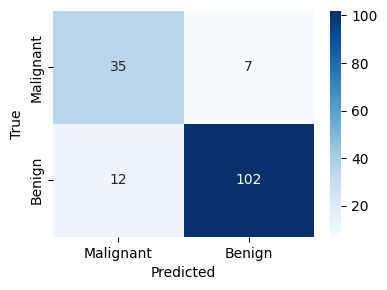

Saved: composite_plots/all_specialists_combined_confusion_matrix_epoch100_acc87.82.svg


In [10]:
if isinstance(config.labels, dict):
    labels = list(config.labels.values())

n_classes = len(labels)
print("The number of classes is:", n_classes)



for epoch in range(1, config.N_EPOCHS + 1):
    print(f"\n=== Epoch {epoch} ===")

    canny_edge_scores = load_scores(
        results_dir=config.SAVE_DIR_SCORES,
        dataset_name=CURRENT_DATASET,
        specialist_name="BreastMNIST_Canny",
        n_epochs=epoch,
        num_clauses=config.NUM_CLAUSES,
        T_best=T_best_canny,
        s_best=s_best_canny,
        patch_best=patch_best_canny,
        maxlit_best=maxlit_best_canny,
        weighted_best=weighted_best
    )

    adaptive_gaussian_scores = load_scores(
    results_dir=config.SAVE_DIR_SCORES,
    dataset_name=CURRENT_DATASET,
    specialist_name="BreastMNIST_Adaptive_Gaussian",
    n_epochs=epoch,
    num_clauses=config.NUM_CLAUSES,
    T_best=T_best_adaptive_gaussian,
    s_best=s_best_adaptive_gaussian,
    patch_best=patch_best_adaptive_gaussian,
    maxlit_best=maxlit_best_adaptive_gaussian,
    weighted_best=weighted_best
)
    adaptive_mean_scores = load_scores(
    results_dir=config.SAVE_DIR_SCORES,
    dataset_name=CURRENT_DATASET,
    specialist_name="BreastMNIST_Adaptive_Mean",
    n_epochs=epoch,
    num_clauses=config.NUM_CLAUSES,
    T_best=T_best_adaptive_mean,
    s_best=s_best_adaptive_mean,
    patch_best=patch_best_adaptive_mean,
    maxlit_best=maxlit_best_adaptive_mean,
    weighted_best=weighted_best
)
    otsu_scores = load_scores(
    results_dir=config.SAVE_DIR_SCORES,
    dataset_name=CURRENT_DATASET,
    specialist_name="BreastMNIST_Otsu",
    n_epochs=epoch,
    num_clauses=config.NUM_CLAUSES,
    T_best=T_best_otsu,
    s_best=s_best_otsu,
    patch_best=patch_best_otsu,
    maxlit_best=maxlit_best_otsu,
    weighted_best=weighted_best
)
    color_thermometer_scores = load_scores(
    results_dir=config.SAVE_DIR_SCORES,
    dataset_name=CURRENT_DATASET,
    specialist_name="BreastMNIST_Color_Thermometers",
    n_epochs=epoch,
    num_clauses=config.NUM_CLAUSES,
    T_best=T_best_thermometer,
    s_best=s_best_thermometer,
    patch_best=patch_best_thermometer,
    maxlit_best=maxlit_best_thermometer,
    weighted_best=weighted_best
)
    
    
    votes = (
        canny_edge_scores +
        adaptive_gaussian_scores+
        adaptive_mean_scores +
        otsu_scores +
        color_thermometer_scores
    )

    Y_test_predicted = votes.argmax(axis=1)
    accuracy = 100.0 * (Y_test_predicted == Y_test).mean()
    print(f"Accuracy: {accuracy:.2f}%")
    if epoch == config.N_EPOCHS:
        cm = confusion_matrix(Y_test, Y_test_predicted)
        fig, ax = plt.subplots(figsize=(4, 3))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                    xticklabels=labels, yticklabels=labels)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")
        plt.tight_layout()
        plt.show()

        composite_dir = "composite_plots"
        os.makedirs(composite_dir, exist_ok=True)
        filename = f"all_specialists_combined_confusion_matrix_epoch{epoch}_acc{accuracy:.2f}.svg"
        save_path = os.path.join(composite_dir, filename)
        fig.savefig(save_path, format="svg", bbox_inches="tight")
        print(f"Saved: {save_path}")



=== All Combinations (sorted by accuracy) ===
otsu + color_thermometer                                                         Accuracy: 89.10%  AUC: 0.8906
adaptive_gaussian + adaptive_mean + otsu + color_thermometer                     Accuracy: 88.46%  AUC: 0.9029
adaptive_gaussian + otsu                                                         Accuracy: 87.82%  AUC: 0.8805
canny + adaptive_mean + otsu                                                     Accuracy: 87.82%  AUC: 0.8834
adaptive_gaussian + otsu + color_thermometer                                     Accuracy: 87.82%  AUC: 0.8978
adaptive_mean + otsu + color_thermometer                                         Accuracy: 87.82%  AUC: 0.9055
canny + adaptive_gaussian + adaptive_mean + otsu                                 Accuracy: 87.82%  AUC: 0.8874
adaptive_mean + color_thermometer                                                Accuracy: 87.18%  AUC: 0.9095
canny + otsu + color_thermometer                                 

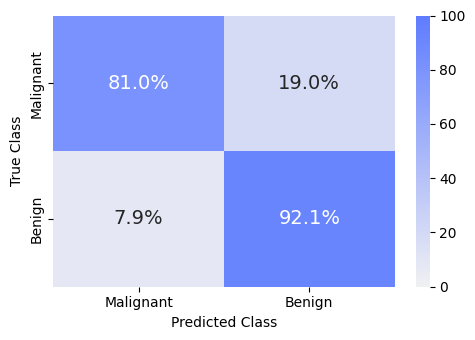

Saved: composite_plots/rank1_confusion_matrix_otsu_+_color_thermometer_acc89.10_auc0.8906.svg


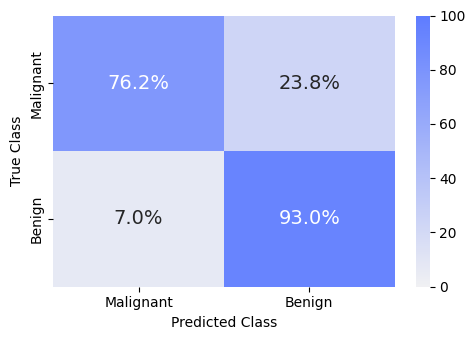

Saved: composite_plots/rank2_confusion_matrix_adaptive_gaussian_+_adaptive_mean_+_otsu_+_color_thermometer_acc88.46_auc0.9029.svg


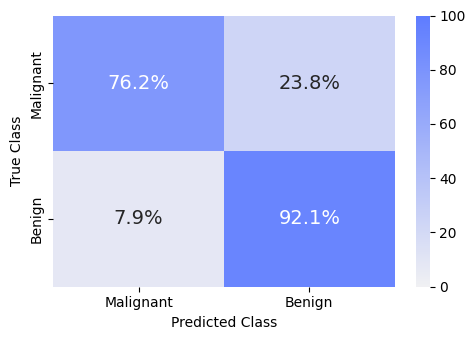

Saved: composite_plots/rank3_confusion_matrix_adaptive_gaussian_+_otsu_acc87.82_auc0.8805.svg


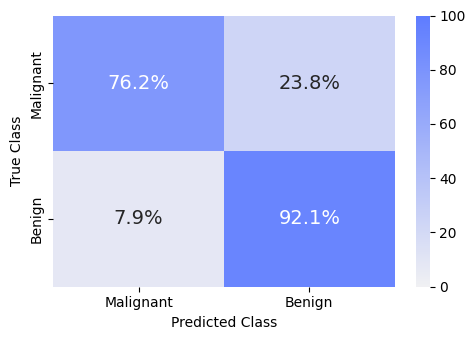

Saved: composite_plots/rank4_confusion_matrix_canny_+_adaptive_mean_+_otsu_acc87.82_auc0.8834.svg


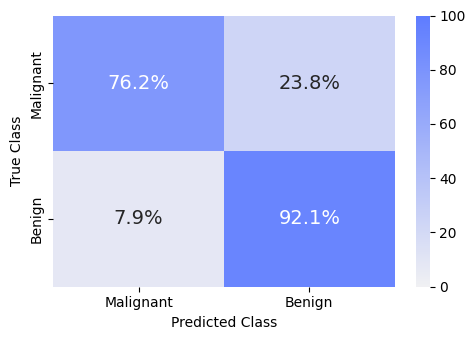

Saved: composite_plots/rank5_confusion_matrix_adaptive_gaussian_+_otsu_+_color_thermometer_acc87.82_auc0.8978.svg


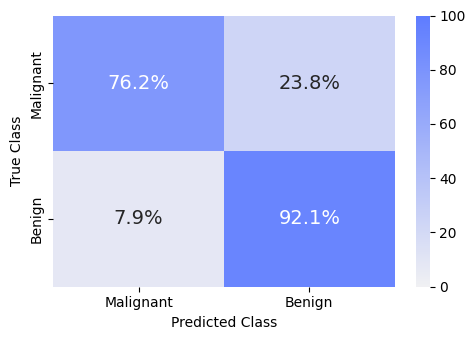

Saved: composite_plots/rank6_confusion_matrix_adaptive_mean_+_otsu_+_color_thermometer_acc87.82_auc0.9055.svg


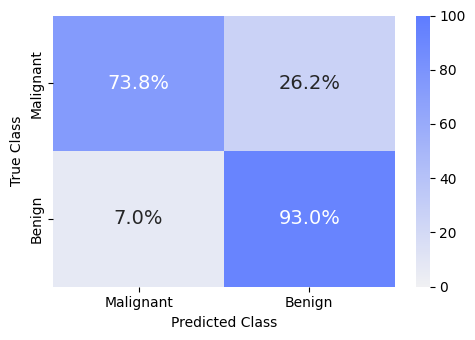

Saved: composite_plots/rank7_confusion_matrix_canny_+_adaptive_gaussian_+_adaptive_mean_+_otsu_acc87.82_auc0.8874.svg


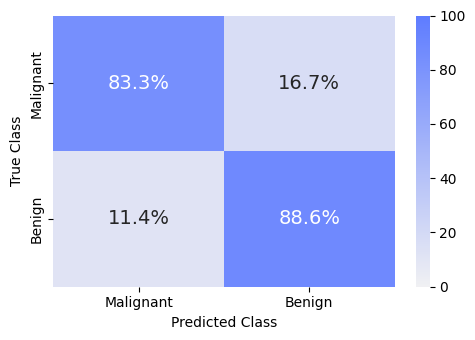

Saved: composite_plots/rank8_confusion_matrix_adaptive_mean_+_color_thermometer_acc87.18_auc0.9095.svg


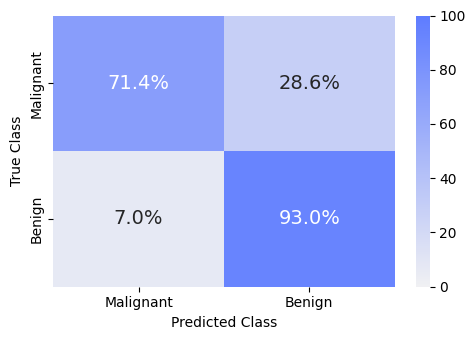

Saved: composite_plots/rank9_confusion_matrix_canny_+_otsu_+_color_thermometer_acc87.18_auc0.8899.svg


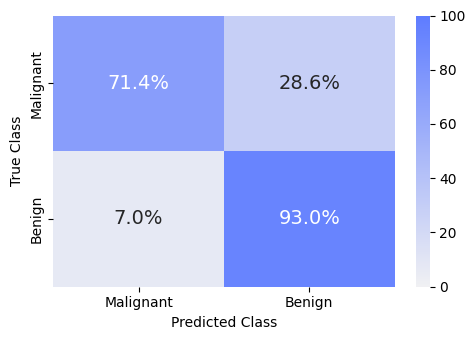

Saved: composite_plots/rank10_confusion_matrix_canny_+_adaptive_gaussian_+_otsu_+_color_thermometer_acc87.18_auc0.8917.svg


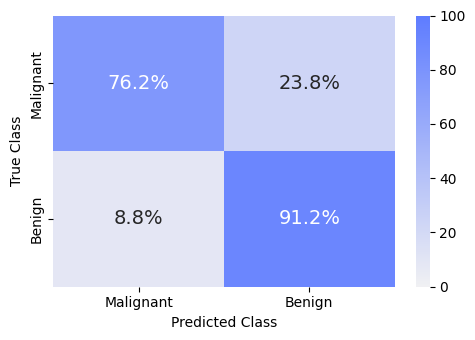

Saved: composite_plots/rank11_confusion_matrix_canny_+_adaptive_gaussian_+_adaptive_mean_+_otsu_+_color_thermometer_acc87.18_auc0.8975.svg


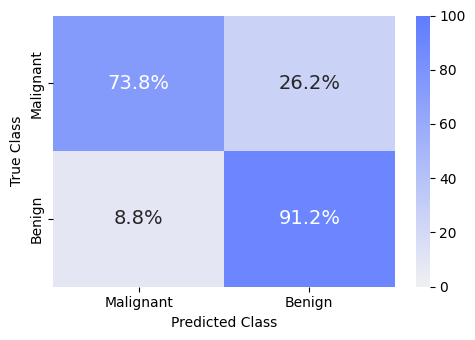

Saved: composite_plots/rank12_confusion_matrix_canny_+_adaptive_mean_acc86.54_auc0.8679.svg


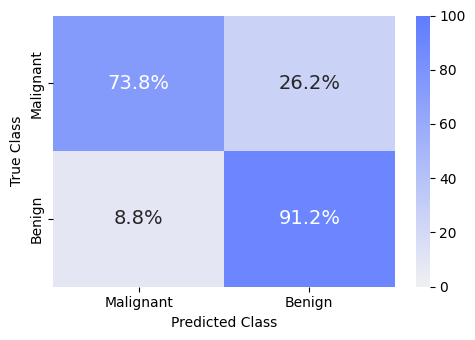

Saved: composite_plots/rank13_confusion_matrix_adaptive_mean_+_otsu_acc86.54_auc0.8910.svg


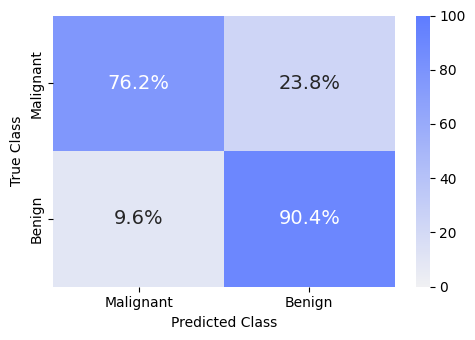

Saved: composite_plots/rank14_confusion_matrix_canny_+_adaptive_gaussian_+_adaptive_mean_acc86.54_auc0.8793.svg


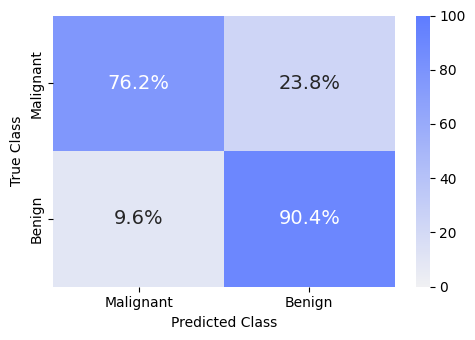

Saved: composite_plots/rank15_confusion_matrix_canny_+_adaptive_gaussian_+_color_thermometer_acc86.54_auc0.8866.svg


In [11]:
import os
import numpy as np
from itertools import combinations
from sklearn.metrics import roc_auc_score, confusion_matrix
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns

# Create output directory
composite_dir = "composite_plots"
os.makedirs(composite_dir, exist_ok=True)

# Composite color
COMPOSITE_CMAP = sns.light_palette("#5e7cff", as_cmap=True)

specialist_names = [
    "canny",
    "adaptive_gaussian",
    "adaptive_mean",
    "otsu",
    "color_thermometer"
]

all_scores = {
    "canny": canny_edge_scores,
    "adaptive_gaussian": adaptive_gaussian_scores,
    "adaptive_mean": adaptive_mean_scores,
    "otsu": otsu_scores,
    "color_thermometer": color_thermometer_scores,
}

alphas = {
    name: scores.max() - scores.min()
    for name, scores in all_scores.items()
}

best_accuracy = -1
best_auc = -1
best_combination = None
results = []

n_classes = list(all_scores.values())[0].shape[1]
Y_test_bin = label_binarize(Y_test, classes=list(range(n_classes)))

def compute_macro_auc(votes, Y_test_bin, n_classes):
    if n_classes == 2:
        return np.mean([
            roc_auc_score(Y_test_bin[:, 0], votes[:, 1]),
            roc_auc_score(1 - Y_test_bin[:, 0], votes[:, 0])
        ])
    return np.mean([
        roc_auc_score(Y_test_bin[:, i], votes[:, i])
        for i in range(n_classes)
    ])

# ============================================================
# Evaluate all combinations
# ============================================================
for r in range(1, len(specialist_names) + 1):
    for combo in combinations(specialist_names, r):
        votes = sum(
            all_scores[name] / alphas[name]
            for name in combo
        )
        Y_pred = votes.argmax(axis=1)
        accuracy = 100.0 * (Y_pred == Y_test).mean()
        macro_auc = compute_macro_auc(votes, Y_test_bin, n_classes)
        results.append((combo, accuracy, macro_auc))
        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_auc = macro_auc
            best_combination = combo

# Sort by accuracy
results.sort(key=lambda x: x[1], reverse=True)

# ============================================================
# Print results
# ============================================================
print("\n=== All Combinations (sorted by accuracy) ===")
for combo, acc, macro_auc in results:
    print(
        f"{' + '.join(combo):<80} "
        f"Accuracy: {acc:.2f}%  "
        f"AUC: {macro_auc:.4f}"
    )

print(f"\n=== Best Combination (by accuracy) ===")
print(f"Specialists: {' + '.join(best_combination)}")
print(f"Accuracy   : {best_accuracy:.2f}%")
print(f"AUC        : {best_auc:.4f}")

# ============================================================
# Save confusion matrices for top combinations
# ============================================================
for rank, (combo, acc, macro_auc) in enumerate(results[:15], start=1):
    votes = sum(
        all_scores[name] / alphas[name]
        for name in combo
    )
    Y_pred = votes.argmax(axis=1)

    cm = confusion_matrix(Y_test, Y_pred)
    cm_percent = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    annot = np.array([
        [f"{cm_percent[i,j]:.1f}%" for j in range(cm.shape[1])]
        for i in range(cm.shape[0])
    ])

    fig, ax = plt.subplots(figsize=(5, 3.5))
    sns.heatmap(
        cm_percent,
        annot=annot,
        fmt="",
        cmap=COMPOSITE_CMAP,
        ax=ax,
        xticklabels=labels,
        yticklabels=labels,
        annot_kws={"size": 14},
        vmin=0,
        vmax=100,
    )
    ax.set_xlabel("Predicted Class")
    ax.set_ylabel("True Class")
    plt.tight_layout()

    combo_str = "_+_".join(combo)
    filename = (
        f"rank{rank}_confusion_matrix_"
        f"{combo_str}_"
        f"acc{acc:.2f}_"
        f"auc{macro_auc:.4f}.svg"
    )
    save_path = os.path.join(
        composite_dir,
        filename
    )
    fig.savefig(
        save_path,
        format="svg",
        bbox_inches="tight"
    )
    plt.show()
    print(f"Saved: {save_path}")